# 问题一：出厂水浊度的影响因素与机器学习分析

本 notebook 从 `data/all_variable_lag_features.xlsx` 读取新的滞后特征数据集，以出厂水浊度 `NTU` 为因变量。除数据来源切换为 `all_variable_lag_features.xlsx` 外，其余分析流程保持不变。读取后首先删除 `NTU` 缺失行，并对其余缺失值采用两种完整案例策略：

1. **方案 A（删除缺失特征）**：删除任何含缺失值的输入特征，保留全部目标有效行。
2. **方案 B（删除缺失行）**：保留全部输入特征，删除任一输入特征含缺失值的行。

两套数据分别执行相同的 PCA、Random Forest、XGBoost、变量重要性、SHAP、Pearson 与 Spearman 相关性分析，并在最后比较结果。模型按时间顺序划分训练集和测试集，只在训练段内进行时间序列交叉验证。


## 1. 环境与依赖

导入分析所需的库，设置随机种子和统一绘图风格。


In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Songti SC", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"pandas: {pd.__version__}")
print(f"SHAP: {shap.__version__}")


pandas: 3.0.2
SHAP: 0.51.0


## 2. 读取新数据并删除目标缺失行

从 `all_variable_lag_features.xlsx` 的 `all_variable_lag_features` 工作表读取新数据，合并 `DATE` 与 `TIME` 形成时间戳并排序。在主分析开始前删除 `NTU` 缺失行，此后的 `raw_df` 仅表示目标值有效的数据。这里只报告删除后的数据规模。


In [19]:
def locate_data_file():
    candidates = [
        Path.cwd() / "data" / "all_variable_lag_features.xlsx",
        Path.cwd().parent / "data" / "all_variable_lag_features.xlsx",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"未找到 all_variable_lag_features.xlsx，已检查：\n{searched}")


def load_excel_sheet(path):
    xls = pd.ExcelFile(path)
    print("Available sheets:", xls.sheet_names)

    preferred_sheet = "all_variable_lag_features"

    if preferred_sheet in xls.sheet_names:
        sheet_to_use = preferred_sheet
    else:
        sheet_to_use = xls.sheet_names[0]
        print(f"Warning: sheet '{preferred_sheet}' not found. Using first sheet: '{sheet_to_use}'")

    df = pd.read_excel(path, sheet_name=sheet_to_use)

    print("Loaded sheet:", sheet_to_use)
    print("Raw data shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    return df


TARGET = "NTU"

DATA_PATH = locate_data_file()
raw_df = load_excel_sheet(DATA_PATH)

# =====================================================
# 新数据已经有 DATETIME，不再使用 DATE + TIME 构造时间
# =====================================================

if "DATETIME" not in raw_df.columns:
    raise KeyError("新数据中没有 DATETIME 列，无法构造时间索引。")

raw_df["TIMESTAMP"] = pd.to_datetime(raw_df["DATETIME"], errors="coerce")

# =====================================================
# 新数据的目标列是 target_NTU，为了不改后面所有代码，
# 这里统一复制成 NTU
# =====================================================

if "target_NTU" in raw_df.columns and "NTU" not in raw_df.columns:
    raw_df["NTU"] = raw_df["target_NTU"]

if TARGET not in raw_df.columns:
    raise KeyError(f"目标变量 {TARGET} 不存在，请检查数据列名。")

raw_df[TARGET] = pd.to_numeric(raw_df[TARGET], errors="coerce")

raw_df = raw_df.sort_values("TIMESTAMP").reset_index(drop=True)

print("TIMESTAMP missing:", raw_df["TIMESTAMP"].isna().sum())
print("Target missing:", raw_df[TARGET].isna().sum())
print("Time range:", raw_df["TIMESTAMP"].min(), "to", raw_df["TIMESTAMP"].max())

raw_df[["DATETIME", "TIMESTAMP", "target_NTU", "NTU"]].head()

Available sheets: ['Sheet1']
Loaded sheet: Sheet1
Raw data shape: (5460, 210)
Columns:
['DATETIME', 'OP_DATE', 'target_NTU', 'RIVER LEVEL_lag0', 'RIVER LEVEL_lag1', 'RIVER LEVEL_lag2', 'RIVER LEVEL_lag3', 'RIVER LEVEL_lag4', 'RIVER LEVEL_lag5', 'RIVER LEVEL_lag6', 'RIVER LEVEL_lag7', 'RIVER LEVEL_lag8', 'RIVER LEVEL_lag9', 'RIVER LEVEL_lag10', 'RIVER LEVEL_lag11', 'RIVER LEVEL_lag12', 'R/W FLOW_lag0', 'R/W FLOW_lag1', 'R/W FLOW_lag2', 'R/W FLOW_lag3', 'R/W FLOW_lag4', 'R/W FLOW_lag5', 'R/W FLOW_lag6', 'R/W FLOW_lag7', 'R/W FLOW_lag8', 'R/W FLOW_lag9', 'R/W FLOW_lag10', 'R/W FLOW_lag11', 'R/W FLOW_lag12', 'R/W NTU_lag0', 'R/W NTU_lag1', 'R/W NTU_lag2', 'R/W NTU_lag3', 'R/W NTU_lag4', 'R/W NTU_lag5', 'R/W NTU_lag6', 'R/W NTU_lag7', 'R/W NTU_lag8', 'R/W NTU_lag9', 'R/W NTU_lag10', 'R/W NTU_lag11', 'R/W NTU_lag12', 'R/W CLR_lag0', 'R/W CLR_lag1', 'R/W CLR_lag2', 'R/W CLR_lag3', 'R/W CLR_lag4', 'R/W CLR_lag5', 'R/W CLR_lag6', 'R/W CLR_lag7', 'R/W CLR_lag8', 'R/W CLR_lag9', 'R/W CLR_lag10', 

,DATETIME,TIMESTAMP,target_NTU,NTU
0,2025-01-01 07:00:00,2025-01-01 07:00:00,0.12,0.12
1,2025-01-01 09:00:00,2025-01-01 09:00:00,0.12,0.12
2,2025-01-01 11:00:00,2025-01-01 11:00:00,0.12,0.12
3,2025-01-01 13:00:00,2025-01-01 13:00:00,0.11,0.11
4,2025-01-01 15:00:00,2025-01-01 15:00:00,0.11,0.11


## 3. 构造两套分析数据

日期、时间、时间戳、备注、目标列和全空字段不作为输入特征。方案 A 删除在 `raw_df` 中出现任何缺失值的输入特征；方案 B 保留全部非全空输入特征，并删除任一输入特征缺失的行。两套数据均不进行插补。


In [20]:
NON_FEATURE_COLUMNS = {"DATE", "TIME", "TIMESTAMP", "REMARKS", TARGET}
all_empty_columns = set(raw_df.columns[raw_df.isna().all()])
candidate_features = [
    column
    for column in raw_df.columns
    if column not in NON_FEATURE_COLUMNS | all_empty_columns
]

scheme_a_features = [
    column for column in candidate_features
    if not raw_df[column].isna().any()
]
scheme_a_df = raw_df.copy()

scheme_b_features = candidate_features.copy()
scheme_b_df = raw_df.dropna(subset=scheme_b_features).copy()

dataset_summary = pd.DataFrame({
    "方案": ["A：删除缺失特征", "B：删除缺失行"],
    "样本数": [len(scheme_a_df), len(scheme_b_df)],
    "输入特征数": [len(scheme_a_features), len(scheme_b_features)],
    "删除的输入特征": [
        ", ".join(sorted(set(candidate_features) - set(scheme_a_features))),
        "无",
    ],
})
display(dataset_summary)
print("方案 A 输入特征：", scheme_a_features)
print("方案 B 输入特征：", scheme_b_features)

# ===============================
# 检查方案 A / B 的缺失情况
# ===============================

def check_missing_status(df, features, target, name):
    cols = features + [target]
    missing_count = df[cols].isna().sum()
    missing_rate = df[cols].isna().mean() * 100

    missing_table = pd.DataFrame({
        "missing_count": missing_count,
        "missing_rate_%": missing_rate
    }).sort_values("missing_rate_%", ascending=False)

    print(f"\n{name} 缺失情况：")
    display(missing_table[missing_table["missing_count"] > 0])

    print(f"{name} 总行数:", len(df))
    print(f"{name} target 缺失行数:", df[target].isna().sum())
    print(f"{name} target 非缺失行数:", df[target].notna().sum())

    return missing_table


missing_a = check_missing_status(
    scheme_a_df,
    scheme_a_features,
    TARGET,
    "方案 A"
)

missing_b = check_missing_status(
    scheme_b_df,
    scheme_b_features,
    TARGET,
    "方案 B"
)
# ===============================
# 构造训练用数据：只删除目标变量缺失的行
# 输入特征缺失后续用 median imputer 处理
# ===============================

scheme_a_train_df = scheme_a_df.dropna(subset=[TARGET]).copy()
scheme_b_train_df = scheme_b_df.dropna(subset=[TARGET]).copy()

print("方案 A 训练数据 shape:", scheme_a_train_df.shape)
print("方案 B 训练数据 shape:", scheme_b_train_df.shape)

print("方案 A 目标缺失:", scheme_a_train_df[TARGET].isna().sum())
print("方案 B 目标缺失:", scheme_b_train_df[TARGET].isna().sum())


,方案,样本数,输入特征数,删除的输入特征
0,A：删除缺失特征,5460,11,"ALUM_lag0, ALUM_lag1, ALUM_lag10, ALUM_lag11, ..."
1,B：删除缺失行,3249,210,无


方案 A 输入特征： ['DATETIME', 'OP_DATE', 'RIVER LEVEL_lag0', 'R/W FLOW_lag0', 'R/W NTU_lag0', 'R/W CLR_lag0', 'FILT. NTU_lag0', 'C/W WELL LEVEL_lag0', 'CLR_lag0', 'F/RIDE_lag0', 'T/W FLOW_lag0']
方案 B 输入特征： ['DATETIME', 'OP_DATE', 'target_NTU', 'RIVER LEVEL_lag0', 'RIVER LEVEL_lag1', 'RIVER LEVEL_lag2', 'RIVER LEVEL_lag3', 'RIVER LEVEL_lag4', 'RIVER LEVEL_lag5', 'RIVER LEVEL_lag6', 'RIVER LEVEL_lag7', 'RIVER LEVEL_lag8', 'RIVER LEVEL_lag9', 'RIVER LEVEL_lag10', 'RIVER LEVEL_lag11', 'RIVER LEVEL_lag12', 'R/W FLOW_lag0', 'R/W FLOW_lag1', 'R/W FLOW_lag2', 'R/W FLOW_lag3', 'R/W FLOW_lag4', 'R/W FLOW_lag5', 'R/W FLOW_lag6', 'R/W FLOW_lag7', 'R/W FLOW_lag8', 'R/W FLOW_lag9', 'R/W FLOW_lag10', 'R/W FLOW_lag11', 'R/W FLOW_lag12', 'R/W NTU_lag0', 'R/W NTU_lag1', 'R/W NTU_lag2', 'R/W NTU_lag3', 'R/W NTU_lag4', 'R/W NTU_lag5', 'R/W NTU_lag6', 'R/W NTU_lag7', 'R/W NTU_lag8', 'R/W NTU_lag9', 'R/W NTU_lag10', 'R/W NTU_lag11', 'R/W NTU_lag12', 'R/W CLR_lag0', 'R/W CLR_lag1', 'R/W CLR_lag2', 'R/W CLR_lag3', 

,missing_count,missing_rate_%
NTU,336,6.153846


方案 A 总行数: 5460
方案 A target 缺失行数: 336
方案 A target 非缺失行数: 5124

方案 B 缺失情况：


,missing_count,missing_rate_%


方案 B 总行数: 3249
方案 B target 缺失行数: 0
方案 B target 非缺失行数: 3249
方案 A 训练数据 shape: (5124, 212)
方案 B 训练数据 shape: (3249, 212)
方案 A 目标缺失: 0
方案 B 目标缺失: 0


## 4. 共用分析函数

以下函数对任意一套完整数据执行完全相同的时间切分、PCA、模型调参、性能评价、变量重要性、SHAP 和相关性分析。数值特征在模型管线中进行标准化，标准化参数仅由各训练折拟合，避免测试数据泄漏。两套方案采用相同随机种子、参数空间、4 折时间序列交叉验证和 80%/20% 时间顺序划分。


In [21]:
def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }


def transformed_feature_metadata(fitted_pipeline, numeric_features, categorical_features):
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    transformed_names = fitted_preprocessor.get_feature_names_out().tolist()
    source_names = list(numeric_features)
    if categorical_features:
        encoder = fitted_preprocessor.named_transformers_["categorical"]
        for column, categories in zip(categorical_features, encoder.categories_):
            source_names.extend([column] * len(categories))
    if len(transformed_names) != len(source_names):
        raise ValueError("转换后特征与原始字段映射长度不一致")
    return transformed_names, source_names


def aggregated_tree_importance(fitted_pipeline, numeric_features, categorical_features):
    transformed_names, source_names = transformed_feature_metadata(
        fitted_pipeline, numeric_features, categorical_features
    )
    detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "importance": fitted_pipeline.named_steps["model"].feature_importances_,
    })
    aggregated = (
        detail.groupby("source_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return aggregated


def compute_shap_results(
    name,
    fitted_pipeline,
    X_source,
    numeric_features,
    categorical_features,
    max_samples=500,
):
    sample_positions = np.linspace(
        0, len(X_source) - 1, min(max_samples, len(X_source)), dtype=int
    )
    X_sample = X_source.iloc[sample_positions]
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    tree_model = fitted_pipeline.named_steps["model"]
    transformed_names, source_names = transformed_feature_metadata(
        fitted_pipeline, numeric_features, categorical_features
    )
    transformed_sample = fitted_preprocessor.transform(X_sample)
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(transformed_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    global_detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    global_aggregated = (
        global_detail.groupby("source_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    return {
        "name": name,
        "values": shap_values,
        "data": transformed_sample,
        "feature_names": transformed_names,
        "aggregated": global_aggregated,
    }


def target_correlations(matrix, target=TARGET):
    result = matrix[target].drop(index=target).dropna().to_frame("correlation")
    result["absolute_correlation"] = result["correlation"].abs()
    return result.sort_values("absolute_correlation", ascending=False)


In [22]:
def run_analysis(scheme_name, analysis_df, feature_columns):
    print("=" * 90)
    print(scheme_name)
    print("=" * 90)

    X = analysis_df[feature_columns].copy()
    y = analysis_df[TARGET].astype(float)
    timestamps = analysis_df["TIMESTAMP"]
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = [
        column for column in feature_columns if column not in numeric_features
    ]
    for column in categorical_features:
        X[column] = X[column].astype(str)

    split_index = int(len(analysis_df) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    time_train, time_test = timestamps.iloc[:split_index], timestamps.iloc[split_index:]

    transformers = []
    if numeric_features:
        numeric_pipeline = Pipeline([
            ("scaler", StandardScaler()),
        ])
        transformers.append(("numeric", numeric_pipeline, numeric_features))
    if categorical_features:
        transformers.append((
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ))
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    print(f"样本数：{len(analysis_df):,}；输入特征数：{len(feature_columns)}")
    print(f"连续特征（{len(numeric_features)} 个）：{numeric_features}")
    print(f"类别特征（{len(categorical_features)} 个）：{categorical_features}")
    print(f"训练集：{len(X_train):,} 条，{time_train.min()} 至 {time_train.max()}")
    print(f"测试集：{len(X_test):,} 条，{time_test.min()} 至 {time_test.max()}")
    assert time_train.max() < time_test.min()
    assert not X.isna().any().any()

    # PCA
    pca_features = [
        column for column in numeric_features
        if analysis_df[column].nunique(dropna=True) > 1
    ]
    pca_input = StandardScaler().fit_transform(analysis_df[pca_features])
    pca = PCA()
    pca_scores = pca.fit_transform(pca_input)
    explained = pd.DataFrame({
        "component": [f"PC{i + 1}" for i in range(pca.n_components_)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
    })
    print("\nPCA 解释方差：")
    display(explained.style.format({
        "explained_variance_ratio": "{:.2%}",
        "cumulative_variance_ratio": "{:.2%}",
    }))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].bar(explained["component"], explained["explained_variance_ratio"])
    axes[0].plot(
        explained["component"],
        explained["cumulative_variance_ratio"],
        color="tab:red",
        marker="o",
        label="累计解释方差",
    )
    axes[0].set_title(f"{scheme_name}：PCA 碎石图")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend()
    scatter = axes[1].scatter(
        pca_scores[:, 0],
        pca_scores[:, 1],
        c=analysis_df[TARGET],
        cmap="viridis",
        alpha=0.55,
        s=16,
    )
    axes[1].set_title(f"{scheme_name}：前两个主成分")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    fig.colorbar(scatter, ax=axes[1], label="NTU")
    plt.tight_layout()
    plt.show()

    loading_count = min(5, pca.n_components_)
    loadings = pd.DataFrame(
        pca.components_[:loading_count].T,
        index=pca_features,
        columns=[f"PC{i + 1}" for i in range(loading_count)],
    )
    display(loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}"))
    for component in loadings.columns:
        top_variables = loadings[component].abs().nlargest(5).index
        print(f"{component} 绝对载荷最高变量：{', '.join(top_variables)}")

    time_cv = TimeSeriesSplit(n_splits=4)
    model_specs = {
        "Random Forest": (
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            {
                "model__n_estimators": [300, 500, 700],
                "model__max_depth": [None, 8, 14, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__max_features": ["sqrt", 0.7, 1.0],
            },
        ),
        "XGBoost": (
            XGBRegressor(
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist",
            ),
            {
                "model__n_estimators": [300, 500, 700],
                "model__learning_rate": [0.02, 0.05, 0.1],
                "model__max_depth": [3, 5, 7],
                "model__min_child_weight": [1, 3, 6],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
                "model__reg_lambda": [1.0, 5.0, 10.0],
            },
        ),
    }
    fitted_models = {}
    predictions = {}
    metrics = {}

    for model_name, (estimator, params) in model_specs.items():
        print(f"\n{model_name} 参数搜索")
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", estimator),
        ])
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=params,
            n_iter=15,
            scoring="neg_root_mean_squared_error",
            cv=time_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            verbose=1,
        )
        search.fit(X_train, y_train)
        fitted_models[model_name] = search.best_estimator_
        predictions[model_name] = search.best_estimator_.predict(X_test)
        metrics[model_name] = regression_metrics(y_test, predictions[model_name])
        print("最优参数：", search.best_params_)

        plt.figure(figsize=(13, 5))
        plt.plot(time_test, y_test, label="实际 NTU", linewidth=1.2)
        plt.plot(
            time_test,
            predictions[model_name],
            label=f"{model_name} 预测",
            linewidth=1.1,
        )
        plt.title(f"{scheme_name} - {model_name}：实际值与预测值")
        plt.xlabel("时间")
        plt.ylabel("NTU")
        plt.legend()
        plt.tight_layout()
        plt.show()

    metrics_table = pd.DataFrame(metrics).T.sort_values("RMSE")
    print("\n模型性能比较：")
    display(metrics_table.style.format("{:.4f}").highlight_min(
        subset=["MAE", "RMSE"], color="#c6efce"
    ).highlight_max(subset=["R2"], color="#c6efce"))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    for axis, model_name in zip(axes, model_specs):
        model_predictions = predictions[model_name]
        axis.scatter(y_test, model_predictions, alpha=0.5, s=18)
        limits = [
            min(y_test.min(), model_predictions.min()),
            max(y_test.max(), model_predictions.max()),
        ]
        axis.plot(limits, limits, "--", color="tab:red")
        axis.set_title(f"{scheme_name} - {model_name}")
        axis.set_xlabel("实际 NTU")
        axis.set_ylabel("预测 NTU")
    plt.tight_layout()
    plt.show()

    importance_tables = {}
    for model_name, fitted_model in fitted_models.items():
        importance_tables[model_name] = aggregated_tree_importance(
            fitted_model, numeric_features, categorical_features
        )
    print("\n原始变量重要性：")
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for axis, model_name in zip(axes, model_specs):
        table = importance_tables[model_name]
        display(table.head(15).style.format({"importance": "{:.4f}"}))
        top = table.head(15).sort_values("importance")
        axis.barh(top["source_feature"], top["importance"])
        axis.set_title(f"{scheme_name} - {model_name} 变量重要性")
    plt.tight_layout()
    plt.show()

    shap_results = {}
    for model_name, fitted_model in fitted_models.items():
        shap_results[model_name] = compute_shap_results(
            model_name,
            fitted_model,
            X_test,
            numeric_features,
            categorical_features,
        )
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for axis, model_name in zip(axes, model_specs):
        result = shap_results[model_name]
        top = result["aggregated"].head(15).sort_values("mean_abs_shap")
        axis.barh(top["source_feature"], top["mean_abs_shap"])
        axis.set_title(f"{scheme_name} - {model_name} 聚合 SHAP")
    plt.tight_layout()
    plt.show()

    for model_name in model_specs:
        result = shap_results[model_name]
        shap.summary_plot(
            result["values"],
            result["data"],
            feature_names=result["feature_names"],
            plot_type="dot",
            max_display=18,
            plot_size=(12, 8),
            color_bar_label="Feature value",
            show=False,
        )
        plt.title(f"{scheme_name} - {model_name} SHAP 分布")
        plt.axvline(0, color="gray", linewidth=1, alpha=0.8)
        plt.tight_layout()
        plt.show()
        display(result["aggregated"].head(15).style.format({"mean_abs_shap": "{:.4f}"}))

    correlation_columns = [
        column for column in feature_columns + [TARGET]
        if pd.api.types.is_numeric_dtype(analysis_df[column])
        and analysis_df[column].nunique(dropna=True) > 1
    ]
    correlation_data = analysis_df[correlation_columns]
    pearson_corr = correlation_data.corr(method="pearson", min_periods=30)
    spearman_corr = correlation_data.corr(method="spearman", min_periods=30)
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for axis, title, matrix in [
        (axes[0], "Pearson 相关系数", pearson_corr),
        (axes[1], "Spearman 相关系数", spearman_corr),
    ]:
        sns.heatmap(
            matrix,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.3,
            cbar_kws={"shrink": 0.75},
            ax=axis,
        )
        axis.set_title(f"{scheme_name} - {title}")
    plt.tight_layout()
    plt.show()

    pearson_target = target_correlations(pearson_corr)
    spearman_target = target_correlations(spearman_corr)
    print("与 NTU 的 Pearson 相关性：")
    display(pearson_target.style.format("{:.4f}"))
    print("与 NTU 的 Spearman 相关性：")
    display(spearman_target.style.format("{:.4f}"))

    return {
        "scheme": scheme_name,
        "n_rows": len(analysis_df),
        "n_features": len(feature_columns),
        "metrics": metrics_table,
        "importance": importance_tables,
        "shap": shap_results,
        "pearson_target": pearson_target,
        "spearman_target": spearman_target,
    }


## 5. 方案 A：删除含缺失值的输入特征

以删除 `NTU` 缺失行后的 `raw_df` 为起点，整体删除任何仍含缺失值的输入特征，然后执行完整分析。


方案 A：删除缺失特征
样本数：5,460；输入特征数：11
连续特征（9 个）：['RIVER LEVEL_lag0', 'R/W FLOW_lag0', 'R/W NTU_lag0', 'R/W CLR_lag0', 'FILT. NTU_lag0', 'C/W WELL LEVEL_lag0', 'CLR_lag0', 'F/RIDE_lag0', 'T/W FLOW_lag0']
类别特征（2 个）：['DATETIME', 'OP_DATE']
训练集：4,368 条，2025-01-01 07:00:00 至 2025-12-31 05:00:00
测试集：1,092 条，2025-12-31 07:00:00 至 2026-04-01 05:00:00

PCA 解释方差：


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,27.15%,27.15%
1,PC2,19.01%,46.16%
2,PC3,12.06%,58.22%
3,PC4,11.14%,69.36%
4,PC5,11.01%,80.37%
5,PC6,8.48%,88.85%
6,PC7,6.58%,95.44%
7,PC8,2.76%,98.20%
8,PC9,1.80%,100.00%


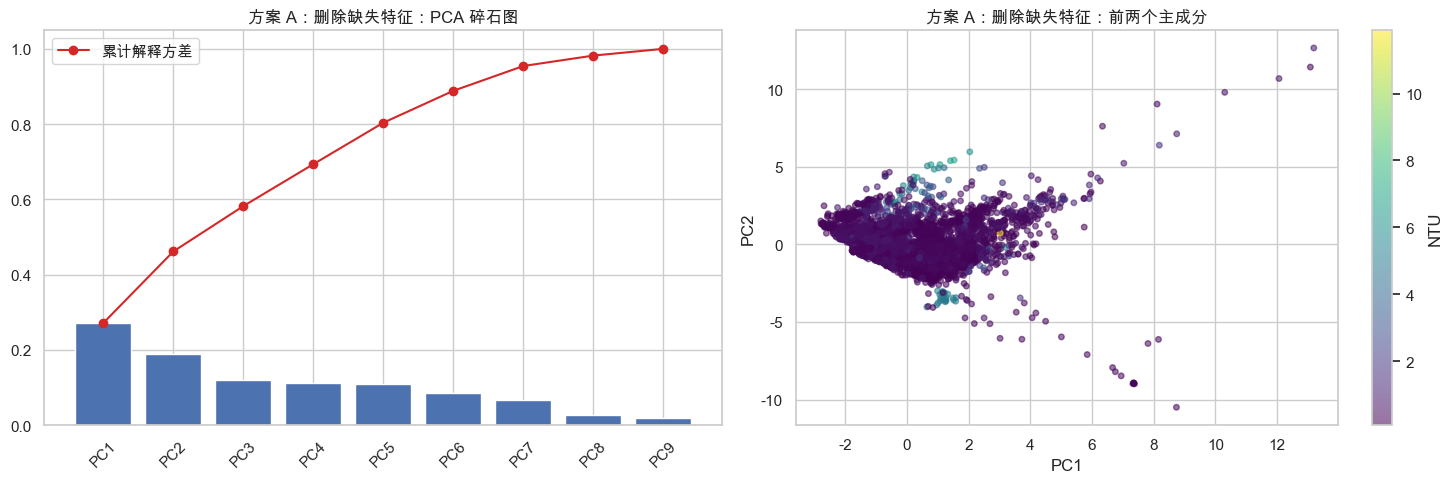

,PC1,PC2,PC3,PC4,PC5
RIVER LEVEL_lag0,0.454,0.139,-0.031,0.086,-0.047
R/W FLOW_lag0,-0.414,0.517,-0.064,-0.019,-0.069
R/W NTU_lag0,0.464,0.390,0.138,-0.035,0.010
R/W CLR_lag0,0.460,0.385,0.156,-0.020,0.027
FILT. NTU_lag0,0.122,0.279,-0.629,-0.100,-0.240
C/W WELL LEVEL_lag0,-0.124,0.184,0.737,-0.097,-0.091
CLR_lag0,-0.032,0.141,-0.103,-0.181,0.949
F/RIDE_lag0,-0.026,0.091,0.000,0.969,0.148
T/W FLOW_lag0,-0.405,0.523,-0.041,0.006,-0.069


PC1 绝对载荷最高变量：R/W NTU_lag0, R/W CLR_lag0, RIVER LEVEL_lag0, R/W FLOW_lag0, T/W FLOW_lag0
PC2 绝对载荷最高变量：T/W FLOW_lag0, R/W FLOW_lag0, R/W NTU_lag0, R/W CLR_lag0, FILT. NTU_lag0
PC3 绝对载荷最高变量：C/W WELL LEVEL_lag0, FILT. NTU_lag0, R/W CLR_lag0, R/W NTU_lag0, CLR_lag0
PC4 绝对载荷最高变量：F/RIDE_lag0, CLR_lag0, FILT. NTU_lag0, C/W WELL LEVEL_lag0, RIVER LEVEL_lag0
PC5 绝对载荷最高变量：CLR_lag0, FILT. NTU_lag0, F/RIDE_lag0, C/W WELL LEVEL_lag0, T/W FLOW_lag0

Random Forest 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits


ValueError: Input contains NaN.

In [23]:
scheme_a_results = run_analysis(
    "方案 A：删除缺失特征",
    scheme_a_df,
    scheme_a_features,
)


## 6. 方案 B：保留全部输入特征并删除缺失行

保留包括 `F/RIDE` 在内的全部非全空输入特征，删除任一输入特征缺失的行，然后执行与方案 A 完全相同的分析。


方案 B：删除缺失行
样本数：1,049；输入特征数：15
连续特征（15 个）：['RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
类别特征（0 个）：[]
训练集：839 条，2025-10-30 15:00:00 至 2026-01-14 17:00:00
测试集：210 条，2026-01-14 19:00:00 至 2026-02-01 05:00:00

PCA 解释方差：


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,25.40%,25.40%
1,PC2,16.33%,41.72%
2,PC3,8.92%,50.64%
3,PC4,8.23%,58.87%
4,PC5,7.90%,66.77%
5,PC6,7.27%,74.04%
6,PC7,6.69%,80.73%
7,PC8,5.66%,86.39%
8,PC9,5.04%,91.43%
9,PC10,4.22%,95.66%


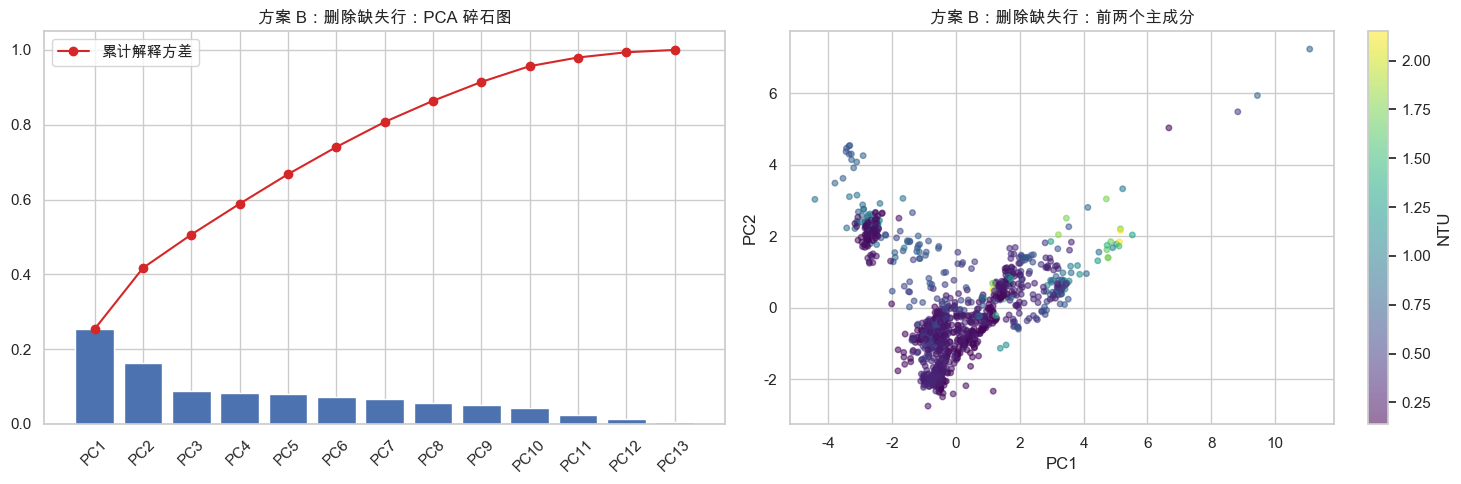

,PC1,PC2,PC3,PC4,PC5
RIVER LEVEL,0.163,0.313,-0.442,0.318,-0.037
R/W PUMP DUTY,-0.114,0.226,-0.140,0.668,-0.392
R/W FLOW,-0.442,0.251,-0.012,0.065,-0.029
R/W NTU,0.454,0.275,0.032,-0.045,0.014
R/W CLR,0.313,0.309,0.014,-0.014,0.044
FILT. NTU,0.322,0.198,0.024,-0.107,0.042
C/W WELL LEVEL,-0.080,-0.156,0.470,0.342,0.234
PH,0.017,0.048,-0.427,0.158,0.678
CL2,-0.200,-0.322,-0.301,0.053,-0.256
F/RIDE,-0.060,-0.023,-0.451,-0.468,-0.262


PC1 绝对载荷最高变量：R/W NTU, R/W FLOW, T/W FLOW, T/W PUMP DUTY, FILT. NTU
PC2 绝对载荷最高变量：T/W PUMP DUTY, ALUM, T/W FLOW, CL2, RIVER LEVEL
PC3 绝对载荷最高变量：C/W WELL LEVEL, F/RIDE, RIVER LEVEL, PH, CL2
PC4 绝对载荷最高变量：R/W PUMP DUTY, F/RIDE, C/W WELL LEVEL, RIVER LEVEL, T/W PUMP DUTY
PC5 绝对载荷最高变量：PH, R/W PUMP DUTY, ALUM, F/RIDE, CL2

Random Forest 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}


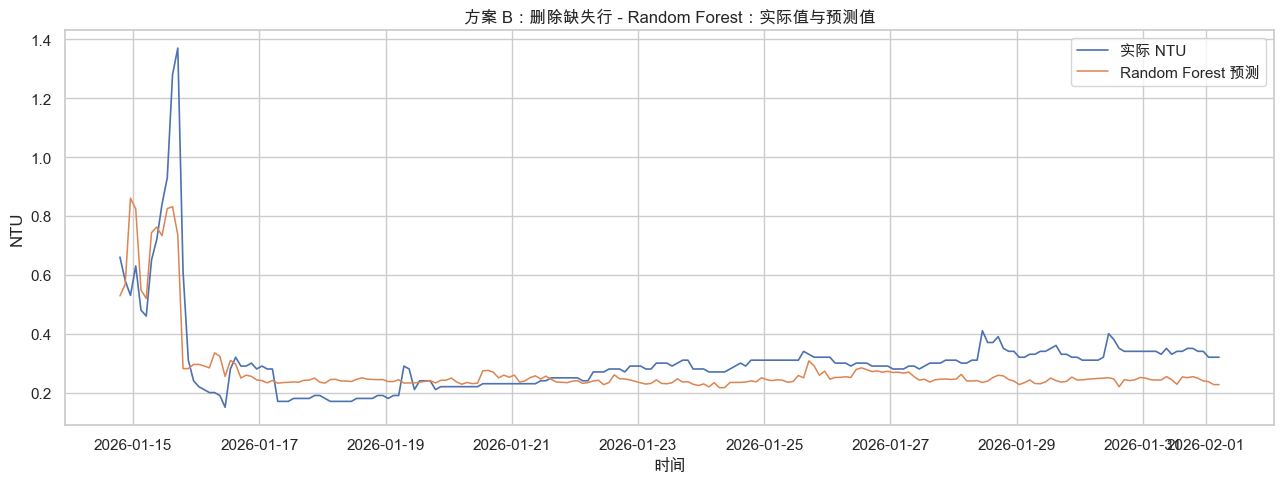


XGBoost 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__subsample': 0.85, 'model__reg_lambda': 5.0, 'model__n_estimators': 700, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.7}


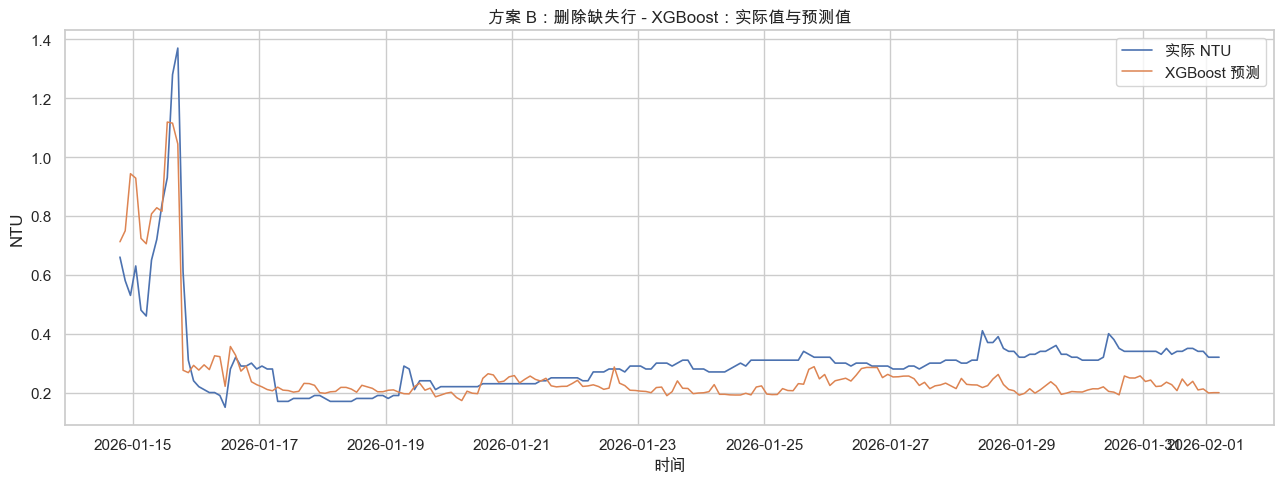


模型性能比较：


,MAE,RMSE,R2
Random Forest,0.0660,0.0921,0.5875
XGBoost,0.0769,0.0976,0.5364


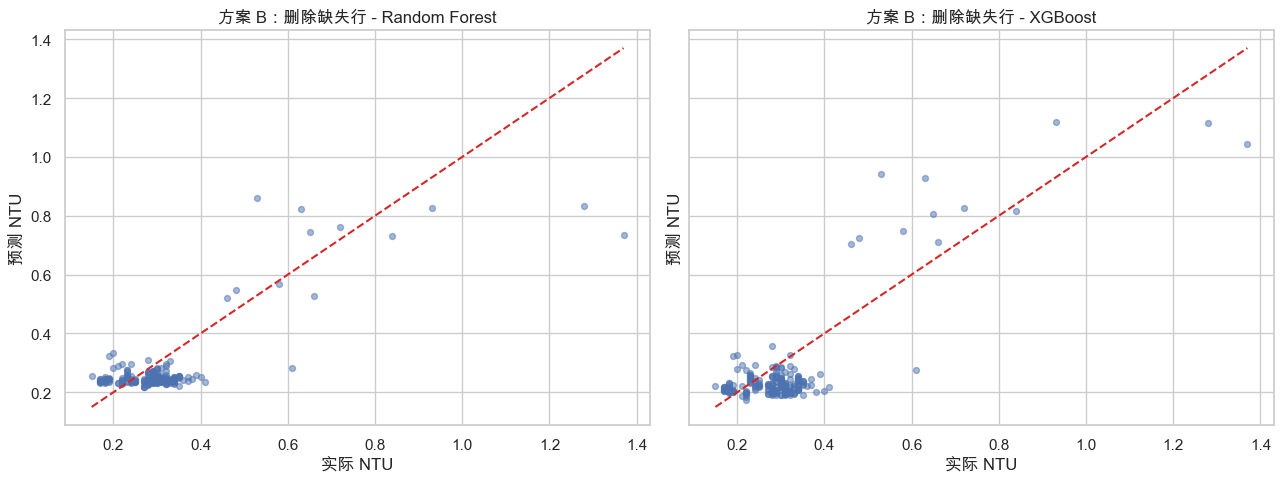


原始变量重要性：


,source_feature,importance
5,FILT. NTU,0.2173
12,RIVER LEVEL,0.1820
9,R/W NTU,0.1281
8,R/W FLOW,0.1210
13,T/W FLOW,0.1139
7,R/W CLR,0.0606
1,C/W WELL LEVEL,0.0473
2,CL2,0.0364
0,ALUM,0.0355
14,T/W PUMP DUTY,0.0305


,source_feature,importance
5,FILT. NTU,0.2018
14,T/W PUMP DUTY,0.1738
0,ALUM,0.1098
11,R/W PUMP DUTY,0.0961
12,RIVER LEVEL,0.0830
13,T/W FLOW,0.0717
8,R/W FLOW,0.0654
9,R/W NTU,0.0583
2,CL2,0.0425
4,F/RIDE,0.0327


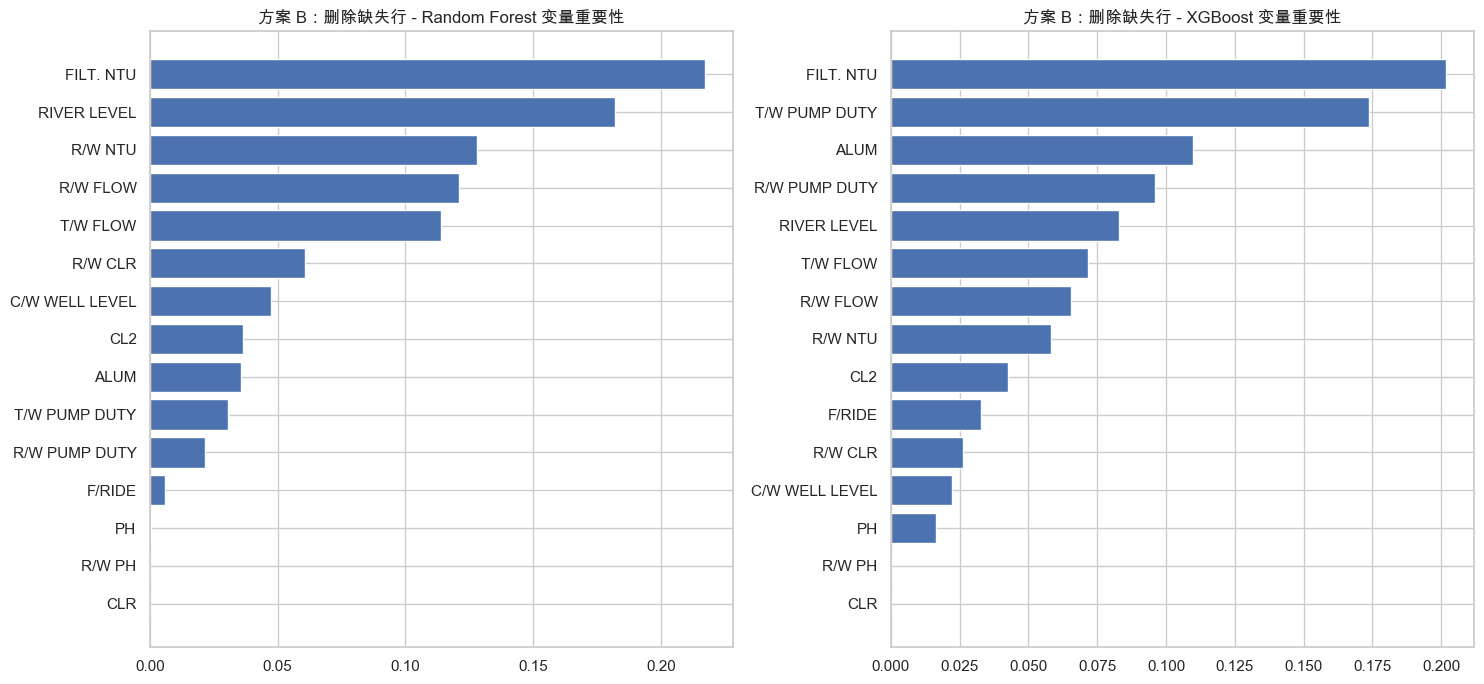

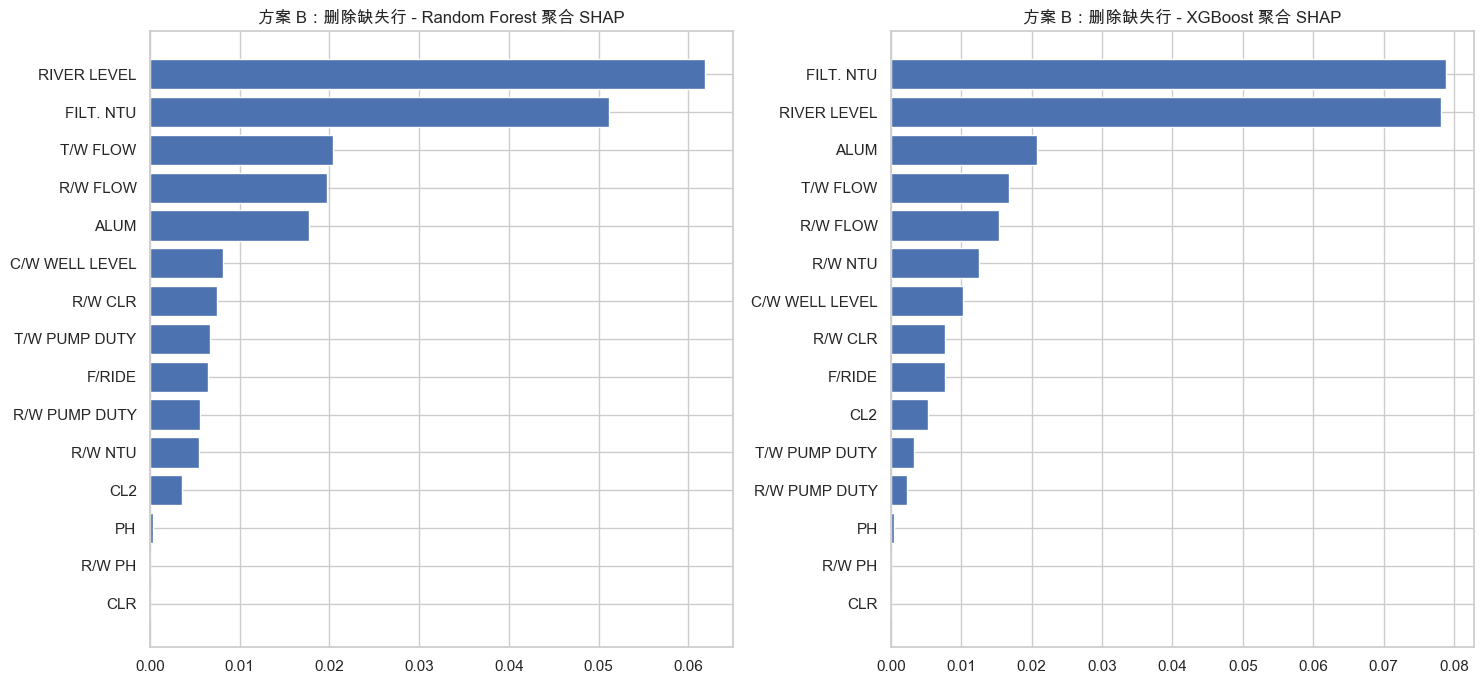

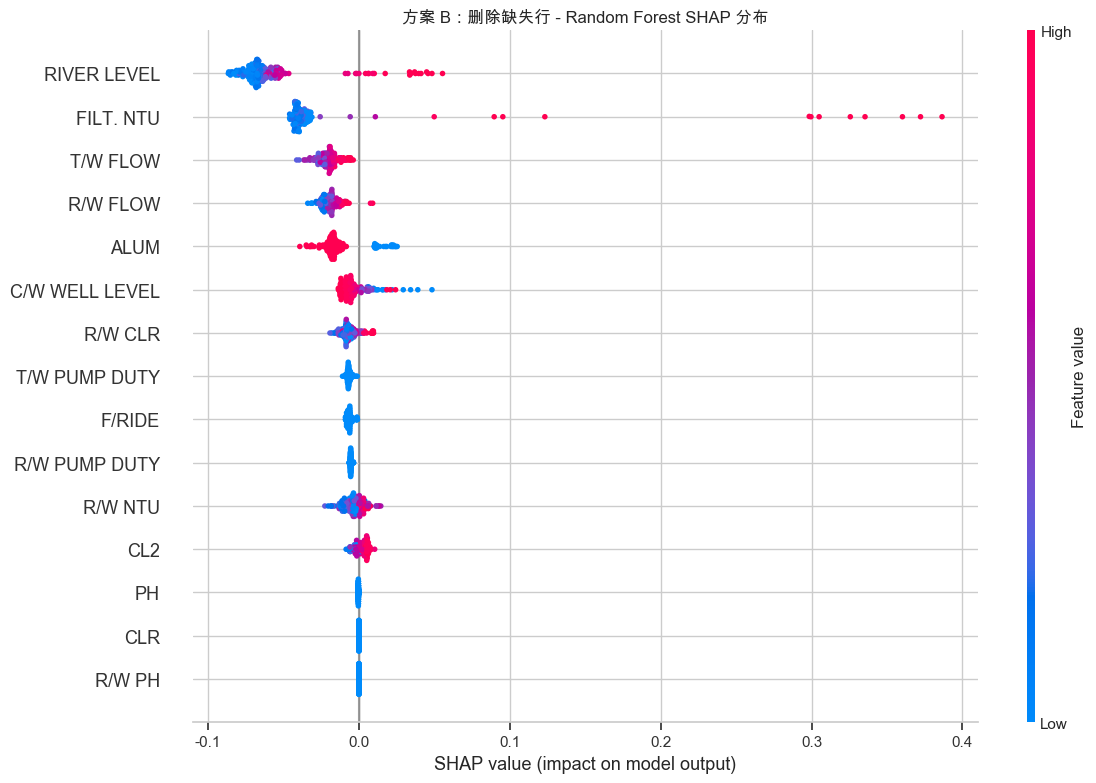

,source_feature,mean_abs_shap
12,RIVER LEVEL,0.0619
5,FILT. NTU,0.0512
13,T/W FLOW,0.0204
8,R/W FLOW,0.0198
0,ALUM,0.0177
1,C/W WELL LEVEL,0.0081
7,R/W CLR,0.0075
14,T/W PUMP DUTY,0.0067
4,F/RIDE,0.0065
11,R/W PUMP DUTY,0.0055


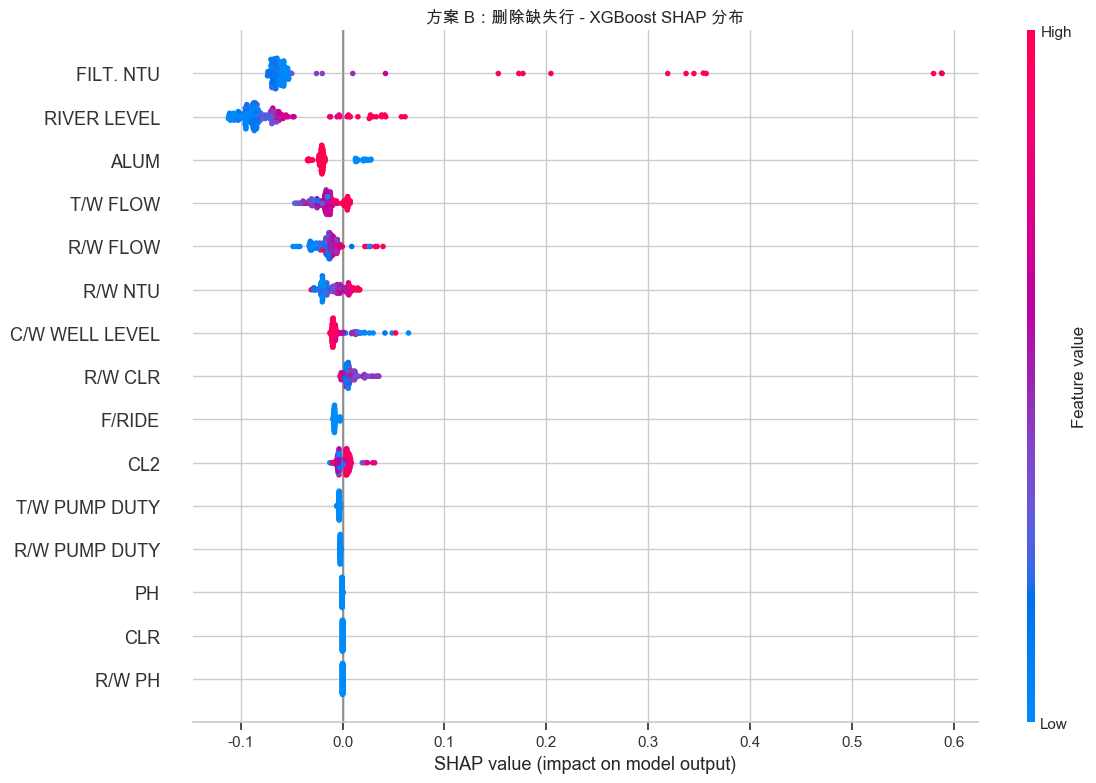

,source_feature,mean_abs_shap
5,FILT. NTU,0.0789
12,RIVER LEVEL,0.0782
0,ALUM,0.0207
13,T/W FLOW,0.0168
8,R/W FLOW,0.0154
9,R/W NTU,0.0125
1,C/W WELL LEVEL,0.0102
7,R/W CLR,0.0077
4,F/RIDE,0.0077
2,CL2,0.0052


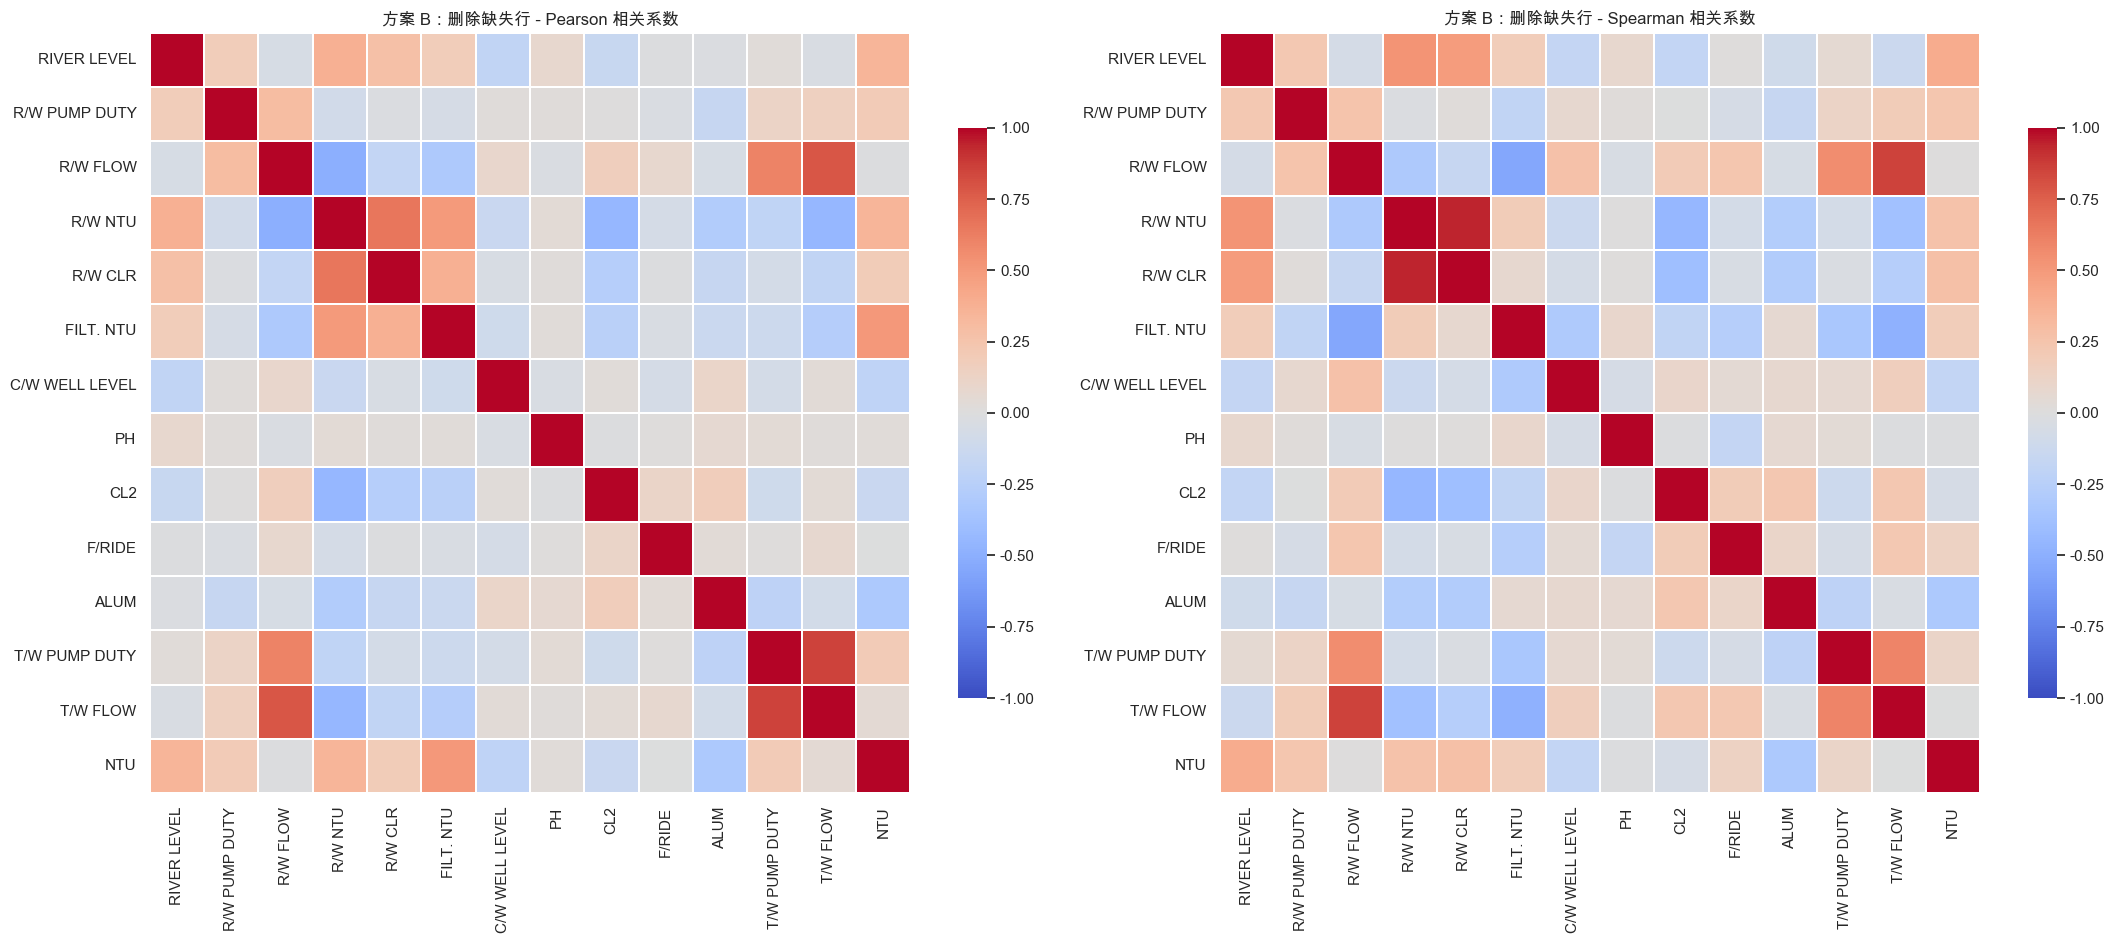

与 NTU 的 Pearson 相关性：


,correlation,absolute_correlation
FILT. NTU,0.5062,0.5062
RIVER LEVEL,0.3514,0.3514
R/W NTU,0.3448,0.3448
ALUM,-0.3177,0.3177
C/W WELL LEVEL,-0.2098,0.2098
R/W PUMP DUTY,0.2021,0.2021
T/W PUMP DUTY,0.1974,0.1974
R/W CLR,0.1880,0.1880
CL2,-0.1461,0.1461
T/W FLOW,0.0529,0.0529


与 NTU 的 Spearman 相关性：


,correlation,absolute_correlation
RIVER LEVEL,0.3988,0.3988
ALUM,-0.3193,0.3193
R/W CLR,0.2742,0.2742
R/W NTU,0.2651,0.2651
R/W PUMP DUTY,0.2367,0.2367
FILT. NTU,0.1868,0.1868
C/W WELL LEVEL,-0.1856,0.1856
F/RIDE,0.1400,0.1400
T/W PUMP DUTY,0.1135,0.1135
CL2,-0.0579,0.0579


In [ ]:
scheme_b_results = run_analysis(
    "方案 B：删除缺失行",
    scheme_b_df,
    scheme_b_features,
)


## 7. 两套方案对比

汇总两套数据的样本数、特征数、Random Forest 与 XGBoost 测试集指标，以及各解释方法排名靠前的变量。由于两套方案的样本时间范围和测试集不同，指标反映的是各自数据处理策略下的预测表现。


In [ ]:
comparison_rows = []
for result in [scheme_a_results, scheme_b_results]:
    for model_name, row in result["metrics"].iterrows():
        comparison_rows.append({
            "方案": result["scheme"],
            "样本数": result["n_rows"],
            "输入特征数": result["n_features"],
            "模型": model_name,
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
        })

model_comparison = pd.DataFrame(comparison_rows).sort_values(["RMSE", "方案"])
display(model_comparison.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2": "{:.4f}",
}).highlight_min(subset=["MAE", "RMSE"], color="#c6efce").highlight_max(
    subset=["R2"], color="#c6efce"
))

summary_rows = []
for result in [scheme_a_results, scheme_b_results]:
    best_model = result["metrics"]["RMSE"].idxmin()
    summary_rows.append({
        "方案": result["scheme"],
        "最佳模型": best_model,
        "最佳 RMSE": result["metrics"].loc[best_model, "RMSE"],
        "RF 重要性前三": ", ".join(
            result["importance"]["Random Forest"].head(3)["source_feature"]
        ),
        "XGB 重要性前三": ", ".join(
            result["importance"]["XGBoost"].head(3)["source_feature"]
        ),
        "RF SHAP 前三": ", ".join(
            result["shap"]["Random Forest"]["aggregated"].head(3)["source_feature"]
        ),
        "XGB SHAP 前三": ", ".join(
            result["shap"]["XGBoost"]["aggregated"].head(3)["source_feature"]
        ),
        "Pearson 前三": ", ".join(result["pearson_target"].head(3).index),
        "Spearman 前三": ", ".join(result["spearman_target"].head(3).index),
    })

summary = pd.DataFrame(summary_rows)
display(summary.style.format({"最佳 RMSE": "{:.4f}"}))
print("注意：上述结果反映统计关联和模型贡献，不等同于因果关系。")


,方案,样本数,输入特征数,模型,MAE,RMSE,R2
2,方案 B：删除缺失行,1049,15,Random Forest,0.0660,0.0921,0.5875
3,方案 B：删除缺失行,1049,15,XGBoost,0.0769,0.0976,0.5364
0,方案 A：删除缺失特征,5124,8,XGBoost,0.2199,0.3864,-0.9091
1,方案 A：删除缺失特征,5124,8,Random Forest,0.2194,0.4130,-1.1817


,方案,最佳模型,最佳 RMSE,RF 重要性前三,XGB 重要性前三,RF SHAP 前三,XGB SHAP 前三,Pearson 前三,Spearman 前三
0,方案 A：删除缺失特征,XGBoost,0.3864,"FILT. NTU, CLR, RIVER LEVEL","CLR, FILT. NTU, R/W FLOW","FILT. NTU, T/W FLOW, RIVER LEVEL","FILT. NTU, T/W FLOW, RIVER LEVEL","FILT. NTU, CLR, R/W FLOW","R/W FLOW, T/W FLOW, FILT. NTU"
1,方案 B：删除缺失行,Random Forest,0.0921,"FILT. NTU, RIVER LEVEL, R/W NTU","FILT. NTU, T/W PUMP DUTY, ALUM","RIVER LEVEL, FILT. NTU, T/W FLOW","FILT. NTU, RIVER LEVEL, ALUM","FILT. NTU, RIVER LEVEL, R/W NTU","RIVER LEVEL, ALUM, R/W CLR"


注意：上述结果反映统计关联和模型贡献，不等同于因果关系。
